# 06 - CNN 2.5D/3D, radiomics y SBR condicionado

Este nodo consume los crops y la tabla del nodo 04 en modo de solo lectura. Compara seis
variantes: imagen, imagen+radiomics independientes del fondo e imagen+radiomics+SBR con
compuerta de validez, para backbones 2.5D y 3D.

La familia de adquisicion se usa unicamente para construir folds congelados y auditar
generalizacion; nunca entra al modelo. Los crops v3 usan una plantilla global de la cohorte,
por lo que sus metricas OOF son desarrollo de competencia, no validacion clinica externa.

In [1]:
from __future__ import annotations

import json
import os
import sys
from contextlib import nullcontext
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modeling.cnn import ExperimentConfig
from modeling.cnn.io import RunLock
from modeling.cnn.pipeline import (
    prepare_experiment,
    run_final_stage,
    run_search_stage,
    validate_path_component,
)
from modeling.cnn.xai_runner import run_xai_audit

RUN_ID = os.environ.get('DAT_CNN_RUN_ID', 'cnn_compact_v1')
NODE4_PROFILE = os.environ.get('DAT_CNN_NODE4_PROFILE', 'v3')
validate_path_component(RUN_ID, 'DAT_CNN_RUN_ID')
validate_path_component(NODE4_PROFILE, 'DAT_CNN_NODE4_PROFILE')
base = ExperimentConfig(run_id=RUN_ID)
experiment = replace(
    base,
    data=replace(base.data, node4_profile=NODE4_PROFILE),
    train=replace(
        base.train,
        max_epochs_search=int(os.environ.get('DAT_CNN_EPOCHS_SEARCH', '12')),
    ),
    search=replace(
        base.search,
        trials_image=int(os.environ.get('DAT_CNN_TRIALS_IMAGE', '20')),
        trials_fusion=int(os.environ.get('DAT_CNN_TRIALS_FUSION', '10')),
        trials_sbr=int(os.environ.get('DAT_CNN_TRIALS_SBR', '8')),
        finalists=int(os.environ.get('DAT_CNN_FINALISTS', '3')),
    ),
)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RUN_DIR = PROJECT_ROOT / 'outputs' / 'private_eda' / 'cnn_runs' / RUN_ID
LOCK_PATH = RUN_DIR / '.run.lock'

def stage_lock():
    if os.environ.get('DAT_CNN_LOCK_HELD') == '1':
        return nullcontext()
    return RunLock(LOCK_PATH)

sns.set_theme(style='whitegrid')
display(Markdown(
    f'**Run:** `{RUN_ID}` - **device:** `{DEVICE}` - '
    f'**hash:** `{experiment.config_hash[:12]}`'
))

**Run:** `cnn_compact_v1` - **device:** `cuda` - **hash:** `3e88e45c3ec1`

## Preparacion reanudable

Normaliza robustamente cada crop sin usar el fondo, genera radiomics core independientes del
fondo, congela folds agrupados 3/5 y persiste un cache compartido. Si se interrumpe, omite
automaticamente los UIDs ya confirmados.

In [2]:
with stage_lock():
    prepared = prepare_experiment(experiment, project_root=PROJECT_ROOT)
display(pd.DataFrame({
    'indicador': ['casos', 'familias', 'fondo valido', 'features core'],
    'valor': [
        len(prepared.cohort),
        prepared.cohort['acquisition_family'].nunique(),
        prepared.cohort['background_qc_valid'].mean(),
        sum(column.startswith('core_') for column in prepared.cohort.columns),
    ],
}))
display(pd.read_csv(prepared.run_dir / 'config' / 'search_fold_summary.csv'))
display(pd.read_csv(prepared.run_dir / 'config' / 'final_fold_summary.csv'))

,indicador,valor
0,casos,1362.000000
1,familias,134.000000
2,fondo valido,0.182819
3,features core,42.000000


,fold,n,pathologic,prevalence,families,background_valid_fraction
0,0,481,279,0.580042,16,0.006237
1,1,440,234,0.531818,88,0.318182
2,2,441,234,0.530612,30,0.240363


,fold,n,pathologic,prevalence,families,background_valid_fraction
0,0,460,273,0.593478,1,0.002174
1,1,195,101,0.517949,25,0.133333
2,2,192,101,0.526042,39,0.317708
3,3,192,101,0.526042,40,0.473958
4,4,323,171,0.529412,29,0.216718


## Busqueda compacta con tres folds

Optuna busca primero el backbone de imagen y despues las ramas de fusion. Usa pruning,
checkpoints por epoca y una base SQLite con heartbeat; un trial interrumpido reusa su
checkpoint. La GPU ejecuta un solo trial a la vez y los DataLoaders paralelizan la lectura.

In [3]:
with stage_lock():
    search_result = run_search_stage(prepared, experiment, device=DEVICE)
display(search_result.summary.style.format({'search_log_loss': '{:.4f}'}))

c:\Users\alana\OneDrive\Documentos\ChatGPT\DaT Scan\dat-parkinsons-challenge\modeling\cnn\search.py:35: ExperimentalWarning: RetryHeartbeatStaleTrialCallback is experimental (supported from v2.8.0). The interface can change in the future.
  retry = optuna.storages.RetryHeartbeatStaleTrialCallback(max_retry=2)
c:\Users\alana\OneDrive\Documentos\ChatGPT\DaT Scan\dat-parkinsons-challenge\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``heartbeat_interval`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\alana\OneDrive\Documentos\ChatGPT\DaT Scan\dat-parkinsons-challenge\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\alana\OneDrive\Documentos\ChatGPT\DaT Scan\dat-parkinsons-challenge\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``cons

[CNN] fold=0 epoch=3/12 train=0.6186 val_log_loss=0.5938 best=0.5938
[CNN] fold=0 epoch=4/12 train=0.6028 val_log_loss=0.5720 best=0.5720
[CNN] fold=0 epoch=5/12 train=0.5796 val_log_loss=0.5941 best=0.5720
[CNN] fold=0 epoch=6/12 train=0.5475 val_log_loss=0.5669 best=0.5669
[CNN] fold=0 epoch=7/12 train=0.5329 val_log_loss=0.6161 best=0.5669
[CNN] fold=0 epoch=8/12 train=0.5171 val_log_loss=0.5445 best=0.5445
[CNN] fold=0 epoch=9/12 train=0.4963 val_log_loss=0.5709 best=0.5445
[CNN] fold=0 epoch=10/12 train=0.4944 val_log_loss=0.5650 best=0.5445
[CNN] fold=0 epoch=11/12 train=0.4735 val_log_loss=0.5813 best=0.5445
[CNN] fold=0 epoch=12/12 train=0.4446 val_log_loss=0.5695 best=0.5445
[CNN] fold=1 epoch=1/12 train=0.6875 val_log_loss=0.6795 best=0.6795
[CNN] fold=1 epoch=2/12 train=0.6840 val_log_loss=0.6531 best=0.6531
[CNN] fold=1 epoch=3/12 train=0.6489 val_log_loss=0.6200 best=0.6200
[CNN] fold=1 epoch=4/12 train=0.5851 val_log_loss=0.6258 best=0.6200
[CNN] fold=1 epoch=5/12 train=0

[I 2026-08-28 11:35:49,431] Trial 6 finished with value: 0.5659300548566071 and parameters: {'tabular_embedding_dim': 24, 'fusion_dropout': 0.23597774791021178, 'fusion_learning_rate': 0.000295364711079743, 'fusion_weight_decay': 8.055612659498582e-05, 'pca': '0.90'}. Best is trial 4 with value: 0.5493048286153009.
[I 2026-08-28 11:36:52,783] Trial 7 finished with value: 0.5883098999280333 and parameters: {'tabular_embedding_dim': 48, 'fusion_dropout': 0.31028036576054524, 'fusion_learning_rate': 0.00029718259782949424, 'fusion_weight_decay': 2.102333672364514e-05, 'pca': '0.90'}. Best is trial 4 with value: 0.5493048286153009.
[I 2026-08-28 11:37:54,825] Trial 8 finished with value: 0.5795169985342886 and parameters: {'tabular_embedding_dim': 16, 'fusion_dropout': 0.38815322088329896, 'fusion_learning_rate': 8.665196271215248e-05, 'fusion_weight_decay': 0.0013318276168653945, 'pca': '0.95'}. Best is trial 4 with value: 0.5493048286153009.
[I 2026-08-28 11:38:35,378] Trial 9 pruned. 
[

[CNN] fold=0 epoch=1/12 train=0.6876 val_log_loss=0.6774 best=0.6774
[CNN] fold=0 epoch=2/12 train=0.6596 val_log_loss=0.6340 best=0.6340
[CNN] fold=0 epoch=3/12 train=0.6113 val_log_loss=0.6157 best=0.6157
[CNN] fold=0 epoch=4/12 train=0.6038 val_log_loss=0.5769 best=0.5769
[CNN] fold=0 epoch=5/12 train=0.5853 val_log_loss=0.5566 best=0.5566
[CNN] fold=0 epoch=6/12 train=0.5347 val_log_loss=0.5336 best=0.5336
[CNN] fold=0 epoch=7/12 train=0.5095 val_log_loss=0.4996 best=0.4996
[CNN] fold=0 epoch=8/12 train=0.5249 val_log_loss=0.5154 best=0.4996
[CNN] fold=0 epoch=9/12 train=0.4959 val_log_loss=0.5822 best=0.4996
[CNN] fold=0 epoch=10/12 train=0.4673 val_log_loss=0.5332 best=0.4996
[CNN] fold=0 epoch=11/12 train=0.4431 val_log_loss=0.5428 best=0.4996
[CNN] fold=1 epoch=1/12 train=0.6910 val_log_loss=0.6854 best=0.6854
[CNN] fold=1 epoch=2/12 train=0.6882 val_log_loss=0.6689 best=0.6689
[CNN] fold=1 epoch=3/12 train=0.6606 val_log_loss=0.5961 best=0.5961
[CNN] fold=1 epoch=4/12 train=0.

[I 2026-08-28 11:57:33,605] Trial 11 finished with value: 0.5308433692471141 and parameters: {'tabular_embedding_dim': 16, 'fusion_dropout': 0.1706282542035742, 'fusion_learning_rate': 0.00037461490163229324, 'fusion_weight_decay': 4.957329978315328e-06, 'pca': '0.90'}. Best is trial 11 with value: 0.5308433692471141.
c:\Users\alana\OneDrive\Documentos\ChatGPT\DaT Scan\dat-parkinsons-challenge\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\alana\OneDrive\Documentos\ChatGPT\DaT Scan\dat-parkinsons-challenge\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-08-28 11:57:33,872] A new study created in RDB with name: cnn_25d_image_radiomics_sbr
c:\Users\alana\OneDrive\Documentos\ChatGPT\DaT Scan\dat-parkinsons-

...

[CNN] fold=0 epoch=1/12 train=0.6981 val_log_loss=0.6579 best=0.6579
[CNN] fold=0 epoch=2/12 train=0.6520 val_log_loss=0.6582 best=0.6579
[CNN] fold=0 epoch=3/12 train=0.6017 val_log_loss=0.6453 best=0.6453
[CNN] fold=0 epoch=4/12 train=0.5673 val_log_loss=0.6352 best=0.6352
[CNN] fold=0 epoch=5/12 train=0.5628 val_log_loss=0.6199 best=0.6199
[CNN] fold=0 epoch=6/12 train=0.5612 val_log_loss=0.6449 best=0.6199
[CNN] fold=0 epoch=7/12 train=0.4934 val_log_loss=0.7388 best=0.6199
[CNN] fold=0 epoch=8/12 train=0.4541 val_log_loss=0.7292 best=0.6199
[CNN] fold=0 epoch=9/12 train=0.4473 val_log_loss=0.7290 best=0.6199
[CNN] fold=1 epoch=1/12 train=0.6908 val_log_loss=0.6887 best=0.6887
[CNN] fold=1 epoch=2/12 train=0.6828 val_log_loss=0.6635 best=0.6635
[CNN] fold=1 epoch=3/12 train=0.6427 val_log_loss=0.5892 best=0.5892
[CNN] fold=1 epoch=4/12 train=0.5832 val_log_loss=0.7310 best=0.5892
[CNN] fold=1 epoch=5/12 train=0.5682 val_log_loss=0.5519 best=0.5519
[CNN] fold=1 epoch=6/12 train=0.53

[I 2026-08-29 10:14:52,669] Trial 11 finished with value: 0.57710357976963 and parameters: {'tabular_embedding_dim': 48, 'fusion_dropout': 0.19159886358990647, 'sbr_hidden_dim': 8, 'fusion_learning_rate': 5.165038190782962e-05, 'fusion_weight_decay': 9.4500055492263e-06, 'pca': '0.90'}. Best is trial 3 with value: 0.5726522052949381.


[CNN] fold=0 epoch=1/12 train=0.7001 val_log_loss=0.6675 best=0.6675
[CNN] fold=0 epoch=2/12 train=0.6489 val_log_loss=0.6584 best=0.6584
[CNN] fold=0 epoch=3/12 train=0.5993 val_log_loss=0.5871 best=0.5871
[CNN] fold=0 epoch=4/12 train=0.5736 val_log_loss=0.6298 best=0.5871
[CNN] fold=0 epoch=5/12 train=0.5741 val_log_loss=0.6689 best=0.5871
[CNN] fold=0 epoch=6/12 train=0.5680 val_log_loss=0.6676 best=0.5871
[CNN] fold=0 epoch=7/12 train=0.4975 val_log_loss=0.7441 best=0.5871
[CNN] fold=1 epoch=1/12 train=0.6910 val_log_loss=0.6853 best=0.6853
[CNN] fold=1 epoch=2/12 train=0.6783 val_log_loss=0.6421 best=0.6421
[CNN] fold=1 epoch=3/12 train=0.6266 val_log_loss=0.5870 best=0.5870
[CNN] fold=1 epoch=4/12 train=0.5759 val_log_loss=0.7581 best=0.5870
[CNN] fold=1 epoch=5/12 train=0.5620 val_log_loss=0.5771 best=0.5771
[CNN] fold=1 epoch=6/12 train=0.5299 val_log_loss=0.6940 best=0.5771
[CNN] fold=1 epoch=7/12 train=0.5148 val_log_loss=0.6293 best=0.5771
[CNN] fold=1 epoch=8/12 train=0.47

[I 2026-08-29 10:26:46,982] Trial 12 finished with value: 0.5706924121999517 and parameters: {'tabular_embedding_dim': 48, 'fusion_dropout': 0.1515630642626501, 'sbr_hidden_dim': 8, 'fusion_learning_rate': 5.565745189458109e-05, 'fusion_weight_decay': 9.625397399697863e-05, 'pca': '0.90'}. Best is trial 12 with value: 0.5706924121999517.


,study_name,architecture,feature_variant,search_log_loss,fixed_epochs,candidate_id,is_finalist
0,cnn_25d_image_radiomics,2.5d,image_radiomics,0.5308,7,c5f41331c124f406,True
1,cnn_25d_image_only,2.5d,image_only,0.5366,7,43765c3f64a985b1,True
2,cnn_25d_image_radiomics_sbr,2.5d,image_radiomics_sbr,0.5430,5,f4c41798fe1e3e53,False
3,cnn_3d_image_radiomics,3d,image_radiomics,0.5610,3,4f0001840e93bffa,True
4,cnn_3d_image_radiomics_sbr,3d,image_radiomics_sbr,0.5707,3,0995022b9063b5cc,False
5,cnn_3d_image_only,3d,image_only,0.5733,3,c9d49f8e868ff799,False


## Evaluacion final con cinco folds congelados

Los dos o tres finalistas se entrenan un numero fijo de epocas derivado de la busqueda. El
fold externo no elige la epoca. Se guardan cinco modelos por configuracion, OOF completo,
calibracion cruzada y un manifiesto del ensemble primario.

[CNN] fold=0 epoch=1/7 train=0.6896 val_log_loss=deferred best=pending
[CNN] fold=0 epoch=2/7 train=0.6628 val_log_loss=deferred best=pending
[CNN] fold=0 epoch=3/7 train=0.6293 val_log_loss=deferred best=pending
[CNN] fold=0 epoch=4/7 train=0.5777 val_log_loss=deferred best=pending
[CNN] fold=0 epoch=5/7 train=0.5374 val_log_loss=deferred best=pending
[CNN] fold=0 epoch=6/7 train=0.5325 val_log_loss=deferred best=pending
[CNN] fold=0 epoch=7/7 train=0.5031 val_log_loss=0.5281 best=0.5281
[CNN] fold=1 epoch=1/7 train=0.6903 val_log_loss=deferred best=pending
[CNN] fold=1 epoch=2/7 train=0.6903 val_log_loss=deferred best=pending
[CNN] fold=1 epoch=3/7 train=0.6891 val_log_loss=deferred best=pending
[CNN] fold=1 epoch=4/7 train=0.6868 val_log_loss=deferred best=pending
[CNN] fold=1 epoch=5/7 train=0.6732 val_log_loss=deferred best=pending
[CNN] fold=1 epoch=6/7 train=0.6566 val_log_loss=deferred best=pending
[CNN] fold=1 epoch=7/7 train=0.6277 val_log_loss=0.5724 best=0.5724
[CNN] fold=2

,candidate_id,architecture,feature_variant,fixed_epochs,raw_log_loss,raw_brier,raw_auc,raw_balanced_accuracy_0_5,raw_ece_10,cross_calibrated_log_loss,cross_calibrated_brier,cross_calibrated_auc,cross_calibrated_balanced_accuracy_0_5,cross_calibrated_ece_10,valid_background_n,valid_background_log_loss,valid_background_brier,invalid_background_n,invalid_background_log_loss,invalid_background_brier,worst_family_log_loss_n10,final_temperature,sbr_promotion_pass
2,43765c3f64a985b1,2.5d,image_only,7,0.5674,0.1927,0.7851,0.7053,0.0590,0.5604,0.1898,0.7834,0.7053,0.0219,249.0000,0.6779,0.2381,1113.0000,0.5341,0.1790,0.8032,1.3052,True
0,c5f41331c124f406,2.5d,image_radiomics,7,0.5646,0.1919,0.7791,0.6982,0.0453,0.5657,0.1920,0.7763,0.6982,0.0376,249.0000,0.6568,0.2293,1113.0000,0.5454,0.1837,0.7857,1.1548,True
1,4f0001840e93bffa,3d,image_radiomics,3,0.5812,0.1976,0.7668,0.7083,0.0524,0.5852,0.1991,0.7606,0.7083,0.0497,249.0000,0.6448,0.2231,1113.0000,0.5718,0.1938,0.8467,1.0431,True


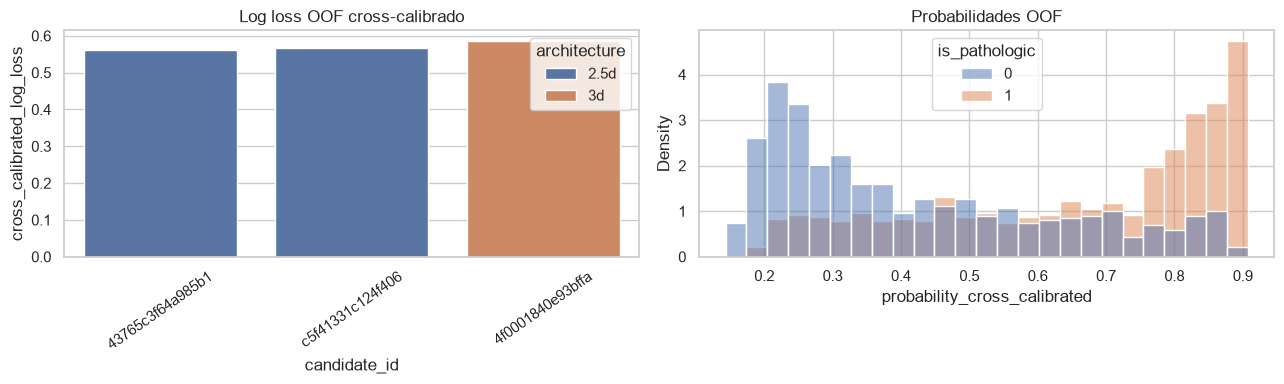

In [4]:
with stage_lock():
    final_result = run_final_stage(prepared, experiment, device=DEVICE)
display(final_result.metrics.style.format(precision=4))

figure, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_metrics = final_result.metrics.copy()
sns.barplot(
    data=plot_metrics,
    x='candidate_id', y='cross_calibrated_log_loss',
    hue='architecture', ax=axes[0],
)
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_title('Log loss OOF cross-calibrado')
sns.histplot(
    data=final_result.oof_predictions,
    x='probability_cross_calibrated', hue='is_pathologic',
    bins=25, stat='density', common_norm=False, ax=axes[1],
)
axes[1].set_title('Probabilidades OOF')
plt.tight_layout()

## Explicabilidad 3D cuantitativa

Se audita el mejor finalista 3D con Grad-CAM, oclusion por bloques y contrafactuales. Cuando
se contradicen, la decision de fidelidad prioriza oclusion y contrafactuales; la contradiccion
queda marcada en vez de ocultarse.

[CNN XAI] 1/24 uid=qxiwe6rg
[CNN XAI] 2/24 uid=nz3a8v4x
[CNN XAI] 3/24 uid=qyz6y3z1
[CNN XAI] 4/24 uid=fdxk31wb
[CNN XAI] 5/24 uid=iaakytt3
[CNN XAI] 6/24 uid=u8iogxpb
[CNN XAI] 7/24 uid=w3stt1eq
[CNN XAI] 8/24 uid=8p6fvdhr
[CNN XAI] 9/24 uid=c5rqnsvs
[CNN XAI] 10/24 uid=vz01sosr
[CNN XAI] 11/24 uid=zublekvl
[CNN XAI] 12/24 uid=y08p0fod
[CNN XAI] 13/24 uid=1g463sdy
[CNN XAI] 14/24 uid=g7f9fzja
[CNN XAI] 15/24 uid=rwk8r2yk
[CNN XAI] 16/24 uid=1w1ht7pz
[CNN XAI] 17/24 uid=wvpunwcg
[CNN XAI] 18/24 uid=hsao2qwk
[CNN XAI] 19/24 uid=gg0v5dta
[CNN XAI] 20/24 uid=t8cq1xgb
[CNN XAI] 21/24 uid=egry58vr
[CNN XAI] 22/24 uid=jdn8ezp7
[CNN XAI] 23/24 uid=be3yqy5f
[CNN XAI] 24/24 uid=u7bfxq7b


,uid,fold,is_pathologic,probability,artifact_path,gradcam_target_fraction,gradcam_target_enrichment,gradcam_background_fraction,occlusion_target_fraction,occlusion_target_enrichment,...,counterfactual_target_attenuation_delta,counterfactual_max_invariant_abs_delta,counterfactual_invariance_failed,spatial_contradiction,direction_contradiction,contradiction,evidence_priority,gradcam_randomized_correlation,gradcam_sanity_pass,counterfactual_scope
0,qxiwe6rg,3,0,0.839486,C:\Users\alana\OneDrive\Documentos\ChatGPT\DaT...,0.404658,1.296436,0.192664,0.667162,2.137445,...,0.001284,0.013971,False,False,False,False,occlusion+counterfactual,0.169332,True,visual_branch_conditioned_on_fixed_tabular_fea...
1,nz3a8v4x,3,0,0.833810,C:\Users\alana\OneDrive\Documentos\ChatGPT\DaT...,0.476061,1.525198,0.253309,0.915118,2.931842,...,0.006036,0.009700,False,False,False,False,occlusion+counterfactual,-0.050826,True,visual_branch_conditioned_on_fixed_tabular_fea...
2,qyz6y3z1,0,0,0.817537,C:\Users\alana\OneDrive\Documentos\ChatGPT\DaT...,0.511185,1.637728,0.324020,0.798626,2.558625,...,0.005998,0.005204,False,False,False,False,occlusion+counterfactual,0.465631,True,visual_branch_conditioned_on_fixed_tabular_fea...
3,fdxk31wb,4,0,0.146887,C:\Users\alana\OneDrive\Documentos\ChatGPT\DaT...,0.274097,0.878148,0.194094,0.817309,2.618483,...,0.044085,0.006560,False,True,False,True,occlusion+counterfactual,0.130560,True,visual_branch_conditioned_on_fixed_tabular_fea...
4,iaakytt3,4,0,0.262346,C:\Users\alana\OneDrive\Documentos\ChatGPT\DaT...,0.378971,1.214143,0.428093,0.923743,2.959476,...,0.058223,0.161791,True,True,False,True,occlusion+counterfactual,0.030886,True,visual_branch_conditioned_on_fixed_tabular_fea...
5,u8iogxpb,4,0,0.808200,C:\Users\alana\OneDrive\Documentos\ChatGPT\DaT...,0.430905,1.380529,0.373059,0.614755,1.969544,...,0.014178,0.038698,False,False,False,False,occlusion+counterfactual,0.372022,True,visual_branch_conditioned_on_fixed_tabular_fea...
6,w3stt1eq,2,0,0.867779,C:\Users\alana\OneDrive\Documentos\ChatGPT\DaT...,0.514556,1.648526,0.308888,0.864531,2.769772,...,-0.000054,0.008802,False,False,False,False,occlusion+counterfactual,0.457781,True,visual_branch_conditioned_on_fixed_tabular_fea...
7,8p6fvdhr,2,0,0.860839,C:\Users\alana\OneDrive\Documentos\ChatGPT\DaT...,0.494311,1.583666,0.289076,0.917612,2.939833,...,0.000022,0.003938,False,False,False,False,occlusion+counterfactual,0.427487,True,visual_branch_conditioned_on_fixed_tabular_fea...
8,c5rqnsvs,3,0,0.859679,C:\Users\alana\OneDrive\Documentos\ChatGPT\DaT...,0.424635,1.360438,0.302318,0.837356,2.682708,...,-0.000141,0.009341,False,False,False,False,occlusion+counterfactual,-0.192509,True,visual_branch_conditioned_on_fixed_tabular_fea...
9,vz01sosr,3,0,0.171271,C:\Users\alana\OneDrive\Documentos\ChatGPT\DaT...,0.192798,0.617683,0.469681,0.945332,3.028641,...,-0.001435,0.003964,False,True,False,True,occlusion+counterfactual,0.066718,True,visual_branch_conditioned_on_fixed_tabular_fea...


n
evidence_priority        contradiction counterfactual_invariance_failed    
occlusion+counterfactual False         False                             13
                         True          False                              7
                         False         True                               3
                         True          True                               1

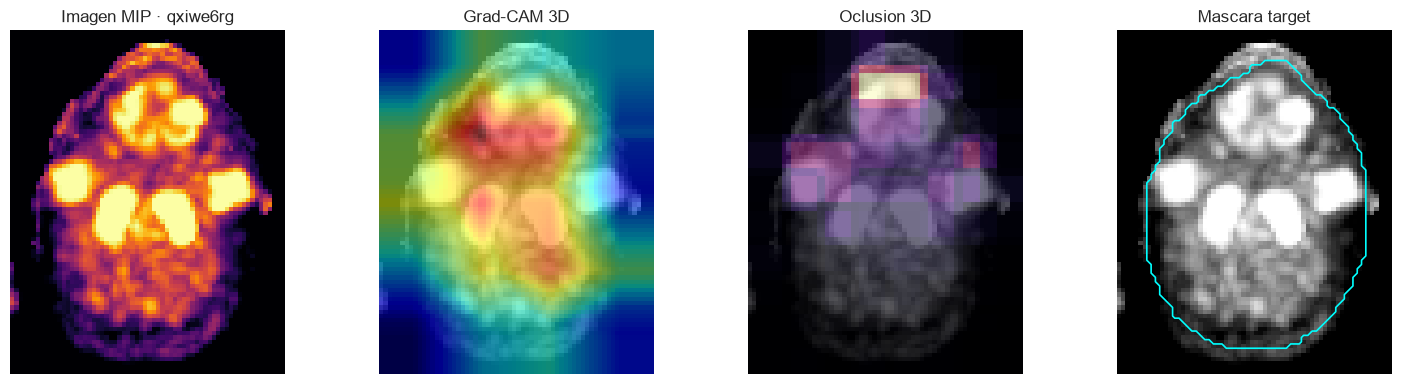

In [5]:
with stage_lock():
    xai_results = run_xai_audit(
        prepared,
        n_cases=int(os.environ.get('DAT_CNN_XAI_CASES', '24')),
        device=DEVICE,
    )
display(xai_results)
display(
    xai_results[
        ['evidence_priority', 'contradiction', 'counterfactual_invariance_failed']
    ].value_counts(dropna=False).rename('n').to_frame()
)

if not xai_results.empty:
    example = xai_results.iloc[0]
    patient = prepared.cohort.set_index('uid').loc[str(example['uid'])]
    with np.load(Path(patient['cache_path']), allow_pickle=False) as source:
        volume = source['volume'].astype(np.float32)
    with np.load(Path(example['artifact_path']), allow_pickle=False) as maps:
        gradcam_map = maps['gradcam'][0, 0].astype(np.float32)
        occlusion_map = maps['occlusion_importance'][0, 0].astype(np.float32)
        target_mask = maps['target_mask'][0, 0].astype(bool)
    image_mip = volume.max(axis=0)
    cam_mip = gradcam_map.max(axis=0)
    occlusion_mip = occlusion_map.max(axis=0)
    mask_mip = target_mask.max(axis=0)
    figure, axes = plt.subplots(1, 4, figsize=(15, 4))
    axes[0].imshow(image_mip, cmap='inferno')
    axes[0].set_title(f"Imagen MIP · {example['uid']}")
    axes[1].imshow(image_mip, cmap='gray')
    axes[1].imshow(cam_mip, cmap='jet', alpha=0.55)
    axes[1].set_title('Grad-CAM 3D')
    axes[2].imshow(image_mip, cmap='gray')
    axes[2].imshow(occlusion_mip, cmap='magma', alpha=0.60)
    axes[2].set_title('Oclusion 3D')
    axes[3].imshow(image_mip, cmap='gray')
    axes[3].contour(mask_mip, levels=[0.5], colors='cyan', linewidths=1.2)
    axes[3].set_title('Mascara target')
    for axis in axes:
        axis.axis('off')
    plt.tight_layout()

## Artefactos principales

- `search/finalists.json`: configuraciones finalistas.
- `final/finalist_cv5_metrics.csv`: comparacion OOF de cinco folds.
- `final/primary_ensemble_manifest.json`: cinco checkpoints y regla de promedio.
- `final/xai/`: mapas y mediciones de Grad-CAM, oclusion y contrafactuales.